# Notebook 1 — Dataset Overview and Structure Inspection

**Project:** P63 – Multimodal Deep Learning for Autoimmune Disease Diagnosis  
**Phase:** Rheumatoid Arthritis (RA) only  
**Dataset:** RAM-H1200-v1 (TokyoTechMagicYang/RAM-H1200-v1)  

---

## What this notebook does

This is the **first notebook** in the pipeline. It inspects the raw dataset at a high level — without modifying anything — and answers the following questions:

1. How many images exist in total and per split?
2. How are images named, and what information is encoded in the filename?
3. How many unique patients are there?
4. Do any patients appear in more than one split (data-leakage risk)?
5. What imaging centres are in the dataset?
6. What are the RA vs Non-RA class counts at the image and patient levels?
7. Do all images on disk have a matching metadata row?

**Output saved:** `outputs/reports/01_dataset_overview.csv`  
**Intermediate result saved:** `outputs/reports/image_manifest.csv`  
(This manifest is used as the starting point for the next notebooks.)

---
## 0. Imports and path configuration

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import sys
from pathlib import Path

# ── Data handling ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Notebook display settings ─────────────────────────────────────────────────
pd.set_option('display.max_columns', None)   # show every column
pd.set_option('display.width', 120)          # wider display
sns.set_theme(style='whitegrid', palette='muted')

print('All imports successful.')

All imports successful.


In [2]:
# ── Path definitions ──────────────────────────────────────────────────────────
# All paths are relative to the FYP project root.
# This notebook lives in FYP/notebooks/, so we go up one level.

PROJECT_ROOT = Path(os.getcwd()).parent   # FYP/

DATASET_DIR   = PROJECT_ROOT / 'Dataset' / 'ra' / 'Segmentation'
METADATA_FILE = PROJECT_ROOT / 'Dataset' / 'ra' / 'Metadata.xlsx'
OUTPUTS_DIR   = PROJECT_ROOT / 'outputs' / 'reports'
PLOTS_DIR     = PROJECT_ROOT / 'outputs' / 'plots'

# Make sure output directories exist
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# The three official splits
SPLITS = ['train', 'val', 'test']

# Verify critical paths exist
assert DATASET_DIR.exists(),   f'Dataset folder not found: {DATASET_DIR}'
assert METADATA_FILE.exists(), f'Metadata file not found: {METADATA_FILE}'

print('PROJECT_ROOT :', PROJECT_ROOT)
print('DATASET_DIR  :', DATASET_DIR)
print('METADATA_FILE:', METADATA_FILE)

PROJECT_ROOT : c:\Users\varsh\OneDrive\Documents\FYP
DATASET_DIR  : c:\Users\varsh\OneDrive\Documents\FYP\Dataset\ra\Segmentation
METADATA_FILE: c:\Users\varsh\OneDrive\Documents\FYP\Dataset\ra\Metadata.xlsx


---
## 1. Count images per split

In [3]:
# ── Count .bmp files in each split folder ─────────────────────────────────────
split_counts = {}
for split in SPLITS:
    folder = DATASET_DIR / split
    bmp_files = list(folder.glob('*.bmp'))
    split_counts[split] = len(bmp_files)

total_images = sum(split_counts.values())

print('─' * 35)
print(f'  Split    │  Images')
print('─' * 35)
for split, count in split_counts.items():
    pct = count / total_images * 100
    print(f'  {split:<8} │  {count:>5}  ({pct:.1f}%)')
print('─' * 35)
print(f'  TOTAL    │  {total_images:>5}')
print('─' * 35)

───────────────────────────────────
  Split    │  Images
───────────────────────────────────
  train    │    793  (66.1%)
  val      │    140  (11.7%)
  test     │    267  (22.2%)
───────────────────────────────────
  TOTAL    │   1200
───────────────────────────────────


---
## 2. Parse image filenames into a structured manifest

Every image filename follows a fixed pattern:

```
{Hospital}_{PatientCode}_{Date}_{4digits}_{Laterality}.bmp
 e.g.  JP_HMCRD_P0001_20210203_6791_L.bmp
```

- **Hospital prefix** – always `JP`
- **Centre code** – e.g. `HMCRD`, `SARC`, `SCGH`, `HU1`, `HU2`, `HU3`
- **Patient code** – e.g. `P0001`
- **Date** – `YYYYMMDD`
- **4-digit suffix** – appears to be an image ID / hash
- **Laterality** – `L` (left hand) or `R` (right hand)

The **base stem** (filename without laterality and `.bmp`) uniquely identifies one exam visit; it maps directly to the `Mapped Image Stem` column in the metadata.

In [4]:
def parse_filename(filename: str, split: str) -> dict:
    """
    Break a BMP filename into its components.
    Returns a dict with all extracted fields, or None if parsing fails.
    """
    stem = filename.replace('.bmp', '')   # remove extension
    parts = stem.split('_')              # split on underscore

    try:
        # The laterality is always the very last part (_L or _R)
        laterality = parts[-1]           # 'L' or 'R'
        base_stem  = '_'.join(parts[:-1])  # everything before _L/_R

        # Centre code is part 1 (after 'JP')
        # e.g. JP_HMCRD_P0001 → parts[0]='JP', parts[1]='HMCRD', parts[2]='P0001'
        centre      = parts[1]
        patient_code = parts[2]   # e.g. 'P0001'
        date_str    = parts[3]    # e.g. '20210203'

        return {
            'filename'     : filename,
            'stem'         : stem,
            'base_stem'    : base_stem,
            'split'        : split,
            'centre'       : centre,
            'patient_code' : patient_code,
            'date'         : date_str,
            'laterality'   : laterality,
        }
    except (IndexError, ValueError):
        # If parsing fails, log it and return None
        print(f'  WARNING: could not parse "{filename}" in split "{split}"')
        return None


# ── Build the manifest DataFrame ──────────────────────────────────────────────
records = []
parse_errors = []

for split in SPLITS:
    folder = DATASET_DIR / split
    for fpath in sorted(folder.glob('*.bmp')):
        row = parse_filename(fpath.name, split)
        if row is None:
            parse_errors.append({'filename': fpath.name, 'split': split})
        else:
            row['full_path'] = str(fpath)  # absolute path for later use
            records.append(row)

manifest = pd.DataFrame(records)

print(f'Manifest shape: {manifest.shape}')
print(f'Parse errors  : {len(parse_errors)}')
print()
manifest.head(5)

Manifest shape: (1200, 9)
Parse errors  : 0



,filename,stem,base_stem,split,centre,patient_code,date,laterality,full_path
0,JP_HMCRD_P0001_20210203_6791_L.bmp,JP_HMCRD_P0001_20210203_6791_L,JP_HMCRD_P0001_20210203_6791,train,HMCRD,P0001,20210203,L,c:\Users\varsh\OneDrive\Documents\FYP\Dataset\...
1,JP_HMCRD_P0001_20210203_6791_R.bmp,JP_HMCRD_P0001_20210203_6791_R,JP_HMCRD_P0001_20210203_6791,train,HMCRD,P0001,20210203,R,c:\Users\varsh\OneDrive\Documents\FYP\Dataset\...
2,JP_HMCRD_P0002_20230413_2984_L.bmp,JP_HMCRD_P0002_20230413_2984_L,JP_HMCRD_P0002_20230413_2984,train,HMCRD,P0002,20230413,L,c:\Users\varsh\OneDrive\Documents\FYP\Dataset\...
3,JP_HMCRD_P0002_20230413_2984_R.bmp,JP_HMCRD_P0002_20230413_2984_R,JP_HMCRD_P0002_20230413_2984,train,HMCRD,P0002,20230413,R,c:\Users\varsh\OneDrive\Documents\FYP\Dataset\...
4,JP_HMCRD_P0006_20241004_2741_L.bmp,JP_HMCRD_P0006_20241004_2741_L,JP_HMCRD_P0006_20241004_2741,train,HMCRD,P0006,20241004,L,c:\Users\varsh\OneDrive\Documents\FYP\Dataset\...


---
## 3. Merge manifest with metadata

The `Mapped Image Stem` column in the metadata corresponds exactly to the `base_stem` we extracted from filenames.

In [5]:
# ── Load the metadata Excel file ──────────────────────────────────────────────
metadata = pd.read_excel(METADATA_FILE)

print('Metadata shape:', metadata.shape)
print('Columns:', list(metadata.columns))
print()
metadata.head(3)

Metadata shape: (836, 10)
Columns: ['Mapped Image Stem', 'StudyID', 'Normalized PatientID', 'isRA', 'Sex', 'Age', 'Center', 'PixelSpacing', 'ImageSize', 'LR']



,Mapped Image Stem,StudyID,Normalized PatientID,isRA,Sex,Age,Center,PixelSpacing,ImageSize,LR
0,JP_HMCRD_P0001_20210203_6791,1,1,0,F,60.0,HMCRD,"[0.15, 0.15]",1670x2010,LR
1,JP_HMCRD_P0002_20230413_2984,1,2,0,F,59.6,HMCRD,"[0.15, 0.15]",1670x2010,LR
2,JP_HMCRD_P0003_20111111_9725,1,3,0,F,54.0,HMCRD,"[0.15, 0.15]",1670x2010,LR


In [6]:
# ── Merge: manifest (per-image) ← metadata (per-exam/case) ───────────────────
# Each metadata row covers one exam (one base_stem), which maps to
# up to two images (left hand + right hand).

df = manifest.merge(
    metadata,
    left_on  = 'base_stem',
    right_on = 'Mapped Image Stem',
    how      = 'left'      # keep all images, even if no metadata match
)

print('Merged DataFrame shape:', df.shape)
print()

# How many images lack a metadata row?
no_meta = df['isRA'].isnull().sum()
print(f'Images with NO metadata match: {no_meta}')
if no_meta > 0:
    print(df[df['isRA'].isnull()][['filename', 'split', 'base_stem']].to_string(index=False))

Merged DataFrame shape: (1200, 19)

Images with NO metadata match: 0


In [7]:
# ── How many metadata rows have NO image on disk? ─────────────────────────────
# (These rows exist in the metadata but the images were not downloaded)

stems_on_disk = set(manifest['base_stem'].unique())
stems_in_meta = set(metadata['Mapped Image Stem'].unique())

only_in_meta = stems_in_meta - stems_on_disk   # in metadata, not on disk
only_on_disk = stems_on_disk - stems_in_meta   # on disk, not in metadata

print(f'Unique base stems on disk        : {len(stems_on_disk)}')
print(f'Unique stems in metadata         : {len(stems_in_meta)}')
print(f'In metadata but NOT on disk      : {len(only_in_meta)}')
print(f'On disk but NOT in metadata      : {len(only_on_disk)}')

Unique base stems on disk        : 790
Unique stems in metadata         : 836
In metadata but NOT on disk      : 46
On disk but NOT in metadata      : 0


---
## 4. Patient-level analysis

Understanding patients is critical for the modelling phase.  
We must ensure that **all images from the same patient stay in the same split** (no patient-level data leakage).

In [8]:
# ── Unique patients in the dataset ────────────────────────────────────────────
n_patients_total = df['Normalized PatientID'].nunique()
print(f'Total unique patients (Normalized PatientID): {n_patients_total}')

# Patients per split
print()
print('Patients per split:')
for split in SPLITS:
    n = df[df['split'] == split]['Normalized PatientID'].nunique()
    print(f'  {split:<6}: {n} patients')

Total unique patients (Normalized PatientID): 218

Patients per split:
  train : 99 patients
  val   : 36 patients
  test  : 100 patients


In [9]:
# ── Patients appearing in MORE than one split (data-leakage check) ─────────────
# Group by patient ID and count how many distinct splits they appear in.

pt_split_count = (
    df.groupby('Normalized PatientID')['split']
    .nunique()
    .reset_index()
    .rename(columns={'split': 'n_splits'})
)

leaked_patients = pt_split_count[pt_split_count['n_splits'] > 1]
print(f'Patients in > 1 split: {len(leaked_patients)}')

if not leaked_patients.empty:
    print()
    print('Detail — which splits does each leaked patient appear in?')
    detail = (
        df[df['Normalized PatientID'].isin(leaked_patients['Normalized PatientID'])]
        .groupby('Normalized PatientID')['split']
        .apply(lambda x: ', '.join(sorted(x.unique())))
        .reset_index()
        .rename(columns={'split': 'splits_present_in'})
    )
    print(detail.to_string(index=False))

Patients in > 1 split: 17

Detail — which splits does each leaked patient appear in?
 Normalized PatientID splits_present_in
                    1        train, val
                    2        train, val
                    3         test, val
                    4       test, train
                    7       test, train
                   26        train, val
                   29       test, train
                   32        train, val
                   38        train, val
                   43       test, train
                   45        train, val
                   46       test, train
                   48       test, train
                   49       test, train
                   50       test, train
                   51       test, train
                   52       test, train


In [10]:
# ── How many images does each patient contribute? (longitudinal check) ─────────
# Some patients have multiple exam visits over time → multiple rows.

imgs_per_patient = df.groupby('Normalized PatientID')['filename'].count()

print('Images per patient — distribution:')
print(imgs_per_patient.describe().round(2))
print()
print('Value counts (how many patients have X images):')
print(imgs_per_patient.value_counts().sort_index())

Images per patient — distribution:
count    218.00
mean       5.50
std        5.78
min        1.00
25%        2.00
50%        2.00
75%        8.00
max       42.00
Name: filename, dtype: float64

Value counts (how many patients have X images):
filename
1       1
2     119
3       3
4      24
6       6
7       1
8      13
9       4
10     13
11      2
12     16
13      2
14      2
16      3
17      1
18      1
20      1
22      1
24      1
26      1
28      1
30      1
42      1
Name: count, dtype: int64


---
## 5. Class distribution (RA vs Non-RA)

`isRA = 1` means the patient has Rheumatoid Arthritis.  
`isRA = 0` means the patient is a Non-RA control.

In [11]:
# ── Image-level class distribution ────────────────────────────────────────────
label_map = {0: 'Non-RA', 1: 'RA'}

class_dist_img = df['isRA'].map(label_map).value_counts()
print('Image-level class distribution:')
print(class_dist_img)
print()
print('As percentages:')
print((class_dist_img / class_dist_img.sum() * 100).round(2))

Image-level class distribution:
isRA
RA        1120
Non-RA      80
Name: count, dtype: int64

As percentages:
isRA
RA        93.33
Non-RA     6.67
Name: count, dtype: float64


In [12]:
# ── Per-split class distribution ──────────────────────────────────────────────
split_class = (
    df.groupby(['split', 'isRA'])
    .size()
    .reset_index(name='count')
)
split_class['label'] = split_class['isRA'].map(label_map)

pivot = split_class.pivot(index='split', columns='label', values='count').fillna(0).astype(int)
pivot['Total'] = pivot.sum(axis=1)
pivot['RA%']   = (pivot['RA'] / pivot['Total'] * 100).round(1)
pivot = pivot.reindex(['train', 'val', 'test'])

print('Class distribution per split (image level):')
print(pivot)

# Note on class imbalance
overall_ra_pct = (df['isRA'].sum() / len(df) * 100)
print(f'\nOverall RA percentage: {overall_ra_pct:.1f}%')
print('CLASS IMBALANCE: The dataset is heavily skewed toward RA images.')

Class distribution per split (image level):
label  Non-RA   RA  Total   RA%
split                          
train      74  719    793  90.7
val         4  136    140  97.1
test        2  265    267  99.3

Overall RA percentage: 93.3%
CLASS IMBALANCE: The dataset is heavily skewed toward RA images.


In [13]:
# ── Patient-level class distribution ──────────────────────────────────────────
# Collapse to one row per patient to see how many unique patients are RA vs Non-RA.

patient_level = df.drop_duplicates(subset='Normalized PatientID')[['Normalized PatientID', 'isRA']]
pt_class = patient_level['isRA'].map(label_map).value_counts()

print('Patient-level class distribution:')
print(pt_class)
print()
print('As percentages:')
print((pt_class / pt_class.sum() * 100).round(2))

Patient-level class distribution:
isRA
RA        183
Non-RA     35
Name: count, dtype: int64

As percentages:
isRA
RA        83.94
Non-RA    16.06
Name: count, dtype: float64


---
## 6. Imaging centre distribution

In [14]:
# ── Centre breakdown (image level) ────────────────────────────────────────────
centre_dist = df['centre'].value_counts()
print('Images per imaging centre:')
print(centre_dist)
print()

# Cross-tab: centre × isRA
print('Centre × isRA cross-table (image counts):')
ct = pd.crosstab(df['centre'], df['isRA'].map(label_map))
ct['Total'] = ct.sum(axis=1)
print(ct)

Images per imaging centre:
centre
HMCRD    688
SARC     368
SCGH     114
HU2       24
HU1        4
HU3        2
Name: count, dtype: int64

Centre × isRA cross-table (image counts):
isRA    Non-RA   RA  Total
centre                    
HMCRD       74  614    688
HU1          4    0      4
HU2          0   24     24
HU3          2    0      2
SARC         0  368    368
SCGH         0  114    114


---
## 7. Visualisations

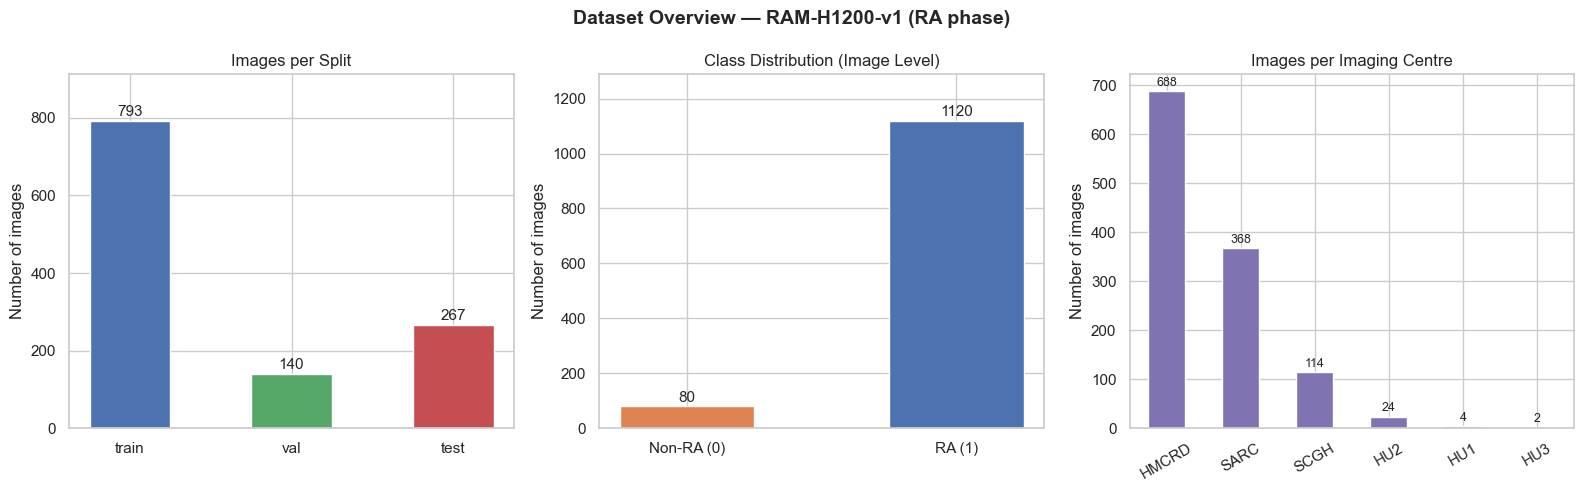

Plot saved → c:\Users\varsh\OneDrive\Documents\FYP\outputs\plots\01_dataset_overview.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dataset Overview — RAM-H1200-v1 (RA phase)', fontsize=14, fontweight='bold')

# ── Plot 1: Images per split ───────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(split_counts.keys(), split_counts.values(),
              color=['#4C72B0', '#55A868', '#C44E52'], edgecolor='white', width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11)
ax.set_title('Images per Split')
ax.set_ylabel('Number of images')
ax.set_ylim(0, max(split_counts.values()) * 1.15)

# ── Plot 2: RA vs Non-RA (image level) ────────────────────────────────────────
ax = axes[1]
labels = ['Non-RA (0)', 'RA (1)']
counts = [int((df['isRA'] == 0).sum()), int((df['isRA'] == 1).sum())]
colors = ['#DD8452', '#4C72B0']
bars2 = ax.bar(labels, counts, color=colors, edgecolor='white', width=0.5)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=11)
ax.set_title('Class Distribution (Image Level)')
ax.set_ylabel('Number of images')
ax.set_ylim(0, max(counts) * 1.15)

# ── Plot 3: Images per imaging centre ─────────────────────────────────────────
ax = axes[2]
centre_dist.plot(kind='bar', ax=ax, color='#8172B2', edgecolor='white')
ax.set_title('Images per Imaging Centre')
ax.set_ylabel('Number of images')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
save_path = PLOTS_DIR / '01_dataset_overview.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved → {save_path}')

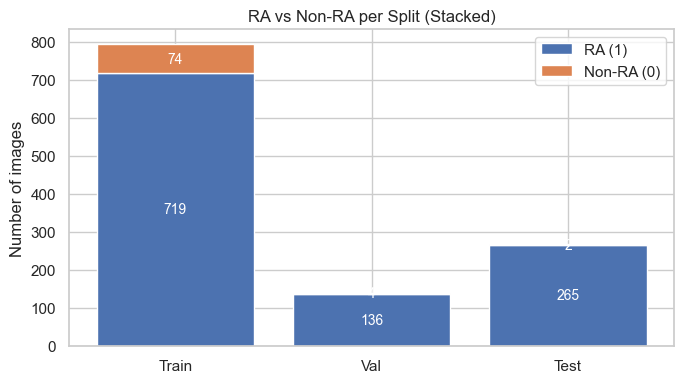

Plot saved → c:\Users\varsh\OneDrive\Documents\FYP\outputs\plots\01_class_per_split.png


In [16]:
# ── Stacked bar: class distribution per split ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

splits_ordered = ['train', 'val', 'test']
ra_counts     = [int(df[(df['split'] == s) & (df['isRA'] == 1)].shape[0]) for s in splits_ordered]
non_ra_counts = [int(df[(df['split'] == s) & (df['isRA'] == 0)].shape[0]) for s in splits_ordered]

x = range(len(splits_ordered))
b1 = ax.bar(x, ra_counts,     label='RA (1)',     color='#4C72B0', edgecolor='white')
b2 = ax.bar(x, non_ra_counts, bottom=ra_counts,   label='Non-RA (0)', color='#DD8452', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels([s.capitalize() for s in splits_ordered])
ax.set_ylabel('Number of images')
ax.set_title('RA vs Non-RA per Split (Stacked)')
ax.legend()

# Annotate each segment
for i, (ra, nra) in enumerate(zip(ra_counts, non_ra_counts)):
    ax.text(i, ra / 2, str(ra),  ha='center', va='center', color='white', fontsize=10)
    ax.text(i, ra + nra / 2, str(nra), ha='center', va='center', color='white', fontsize=10)

plt.tight_layout()
save_path2 = PLOTS_DIR / '01_class_per_split.png'
plt.savefig(save_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved → {save_path2}')

---
## 8. Summary report

Compile all key findings into a single summary table and save it.

In [17]:
summary = {
    'total_images'                 : total_images,
    'train_images'                 : split_counts['train'],
    'val_images'                   : split_counts['val'],
    'test_images'                  : split_counts['test'],
    'unique_base_stems_on_disk'    : len(stems_on_disk),
    'unique_patients'              : n_patients_total,
    'patients_in_multiple_splits'  : len(leaked_patients),
    'ra_images'                    : int((df['isRA'] == 1).sum()),
    'non_ra_images'                : int((df['isRA'] == 0).sum()),
    'ra_pct'                       : round(overall_ra_pct, 2),
    'metadata_rows'                : len(metadata),
    'metadata_stems_not_on_disk'   : len(only_in_meta),
    'disk_stems_not_in_metadata'   : len(only_on_disk),
    'imaging_centres'              : df['centre'].nunique(),
    'image_format'                 : 'BMP',
    'laterality_values'            : 'L, R',
}

summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['value'])
print('=== Dataset Overview Summary ===')
print(summary_df.to_string())

# Save
out_path = OUTPUTS_DIR / '01_dataset_overview.csv'
summary_df.to_csv(out_path)
print(f'\nSummary saved → {out_path}')

=== Dataset Overview Summary ===
                             value
total_images                  1200
train_images                   793
val_images                     140
test_images                    267
unique_base_stems_on_disk      790
unique_patients                218
patients_in_multiple_splits     17
ra_images                     1120
non_ra_images                   80
ra_pct                       93.33
metadata_rows                  836
metadata_stems_not_on_disk      46
disk_stems_not_in_metadata       0
imaging_centres                  6
image_format                   BMP
laterality_values             L, R

Summary saved → c:\Users\varsh\OneDrive\Documents\FYP\outputs\reports\01_dataset_overview.csv


---
## 9. Save the image manifest

This CSV is the **bridge to the next notebooks**.  
It contains one row per image, with all filename-parsed fields and merged metadata.

In [18]:
manifest_out = OUTPUTS_DIR / 'image_manifest.csv'
df.to_csv(manifest_out, index=False)
print(f'Image manifest saved → {manifest_out}')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Image manifest saved → c:\Users\varsh\OneDrive\Documents\FYP\outputs\reports\image_manifest.csv
Shape: (1200, 19)
Columns: ['filename', 'stem', 'base_stem', 'split', 'centre', 'patient_code', 'date', 'laterality', 'full_path', 'Mapped Image Stem', 'StudyID', 'Normalized PatientID', 'isRA', 'Sex', 'Age', 'Center', 'PixelSpacing', 'ImageSize', 'LR']


---
## Summary of findings

| Fact | Value |
|---|---|
| Total images | 1200 BMP files |
| Train / Val / Test | 793 / 140 / 267 |
| Unique exam cases (base stems) | 790 |
| Unique patients | 218 |
| Patients spanning >1 split | 17 (**leakage risk** — noted for later) |
| RA images | 1120 (93.3%) |
| Non-RA images | 80 (6.7%) |
| Class imbalance ratio (approx.) | 14 : 1 |
| Metadata rows | 836 (46 rows have no image on disk) |
| Image format | BMP |
| Laterality | L (left hand) and R (right hand) |
| Imaging centres | 6 (HMCRD, SARC, SCGH, HU1, HU2, HU3) |

**Important notes for modelling:**
- The 14:1 class imbalance will need to be addressed (e.g. weighted loss, oversampling, or careful evaluation metrics).
- 17 patients appear across splits — the dataset was split by the original authors; the pre-existing split should be respected as-is unless a patient-stratified re-split is specifically needed.
- Proceed to **Notebook 2** for image-level analysis (dimensions, pixel statistics, corruption checks).